# Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

# Purpose

A Convolutional Autoencoder (CAE) is an unsupervised deep learning model used for:

Image Compression
Image Reconstruction
Feature Extraction
Dimensionality Reduction

The encoder learns a compressed representation (latent space) of the input image, while the decoder reconstructs the original image from this compressed representation.

In [2]:
import os # math calcul, access file
import shutil # visualization,  for moving and copies dataset and file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf #

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [3]:
!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [5]:


# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

Files in the dataset directory: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [6]:


# Construct the full path to the CSV file
landmarks_csv_path = os.path.join(path, 'list_landmarks_align_celeba.csv')

# Read the CSV file into a pandas DataFrame
landmarks_df = pd.read_csv(landmarks_csv_path)

# Display the first 5 rows of the DataFrame
display(landmarks_df.head())

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [7]:
import os
import shutil

source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder, image),
      destination_folder
      )
  print("Copied", len(image), "image")

Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 1

In [8]:
#Data Preprocessing

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

In [9]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [10]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [11]:
validation_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


In [12]:
# build CAE #encoder
input_img= Input(shape=(64, 64,3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)


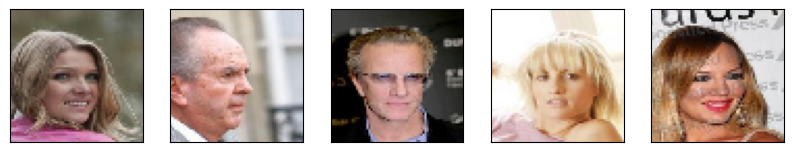

In [13]:
images,_=next(train_generator)

plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])

In [14]:
# build CAE #encoder
input_img= Input(shape=(64, 64,3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)


In [15]:
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)



In [16]:
#EnCode
input_img =Input(shape=(64, 64, 3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoder = MaxPooling2D((2, 2), padding='same')(x)
x= UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)


In [17]:
# Create model
autoencoder = Model(input_img, decoded)

In [18]:
#Compile Model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [19]:
#summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,011 (43.01 KB)

 Trainable params: 11,011 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#train model
history = autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.5389 - val_loss: 0.4915
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4876 - val_loss: 0.4856
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.4840 - val_loss: 0.4830
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.4822 - val_loss: 0.4824
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4813 - val_loss: 0.4813
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4803 - val_loss: 0.4802
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.4796 - val_loss: 0.4798
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.4791 - val_loss: 0.4793
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4789 - val_loss: 0.4792
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4786 - val_loss: 0.4797


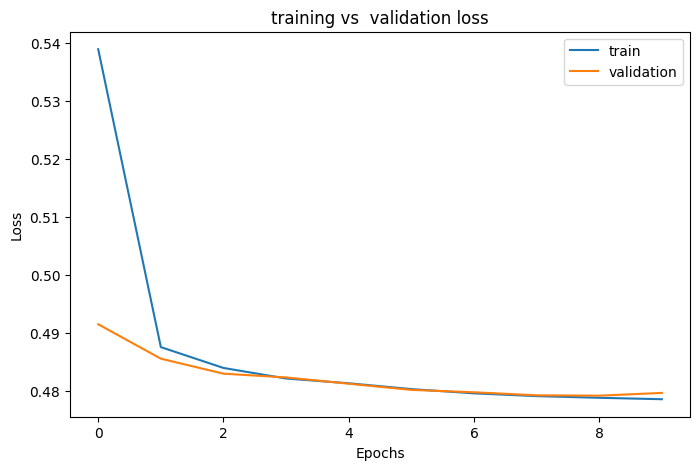

In [21]:
#plot loss
plt.figure(figsize =(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('training vs  validation loss')
plt.legend(['train', 'validation'])
plt.show()


In [22]:
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4797
Validation Loss: 0.47969263792037964


In [23]:
#reconstruct Images
images, _ = next(validation_generator)
decoded_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


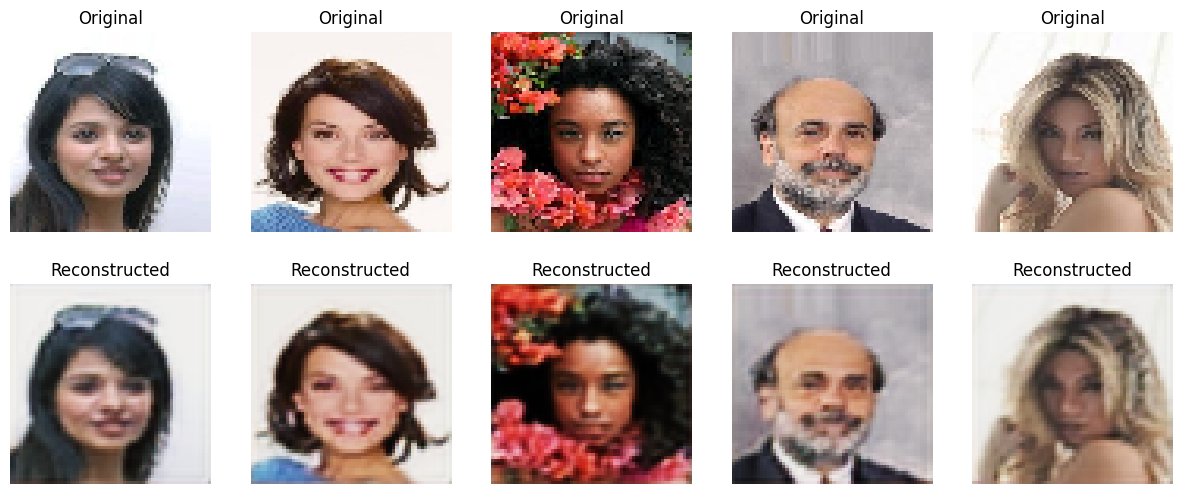

In [24]:
#display Results
n=5
plt.figure(figsize=(15, 6))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()


In [27]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Recompile with a smaller learning rate
autoencoder.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history_tuned = autoencoder.fit(
    train_generator,
    epochs=64,
    callbacks=[early_stop, reduce_lr],
    validation_data=validation_generator,
    verbose=1
)

old_loss = min(history.history['val_loss'])
new_loss = min(history_tuned.history['val_loss'])

print("Validation Loss Before :", old_loss)
print("Validation Loss After  :", new_loss)
print("Improvement : {:.2f}%".format(((old_loss-new_loss)/old_loss)*100))

Epoch 1/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8671 - loss: 0.4777 - val_accuracy: 0.8604 - val_loss: 0.4782 - learning_rate: 5.0000e-05
Epoch 2/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8672 - loss: 0.4777 - val_accuracy: 0.8586 - val_loss: 0.4781 - learning_rate: 5.0000e-05
Epoch 3/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8667 - loss: 0.4777 - val_accuracy: 0.8604 - val_loss: 0.4781 - learning_rate: 5.0000e-05
Epoch 4/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8692 - loss: 0.4781
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8672 - loss: 0.4776 - val_accuracy: 0.8596 - val_loss: 0.4781 - learning_rate: 5.0000e-05
Epoch 5/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8674 - loss: 0.4776 - val_accuracy: 0.8600 - val_loss: 0.4781 - learning_rate: 1.0000e-05
Epoch 6/64
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy